# Initial Organization Of Data

Starting with NANT

#### 1. Open libraries. 
.venv is being a bugger, so extra code is written below if you need to fix the environment too

In [7]:
# # 1) Activate your virtual environment
# ! source /people/gold396/.venv/bin/activate

# # 2) Install/repair pip inside that venv
# ! python -m ensurepip --upgrade

# # 3) Upgrade packaging tools
# ! python -m pip install --upgrade pip setuptools wheel

# # 4) Verify
# ! python -m pip --version
# ! which python

Looking in links: /tmp/tmpfd_5f155
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 8.5 MB/s  0:00:00
  Attempting uninstall: setuptools━━━━━━━━━━━━━━ 0/2 [wheel]
    Found existing installation: setuptools 53.0.00/2 [wheel]
    Uninstalling setuptools-53.0.0:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
      Successfully uninstalled setuptools-53.0.0━━━━━━━━━━━━━━━━━━ 1/2 [setuptools]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [setuptools]2 [setuptools]
pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)
~/ORACLE/.venv/bin/python


In [ ]:
# ! python3 -m venv /people/gold396/ORACLE/.venv --upgrade-deps
# ! source /people/gold396/ORACLE/.venv/bin/activate
# ! python -m pip --version

pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)


In [ ]:
# ! python -m pip --version

pip 26.0.1 from /people/gold396/ORACLE/.venv/lib64/python3.9/site-packages/pip (python 3.9)


In [15]:
! python -m pip install dask[complete] --quiet
! python -m pip install cartopy --quiet

In [ ]:
# ! source /people/gold396/ORACLE/.venv/bin/activate && python -m pip install dask[complete] --quiet && python -m pip install cartopy --quiet

In [ ]:
# ! python -m pip install xarray --quiet

In [1]:
# ! python -m pip install windrose --quiet
from windrose import WindroseAxes

In [2]:
import dask
import pandas as pd
import numpy as np
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.collections import LineCollection
import matplotlib.axes as maxes
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
from io import BytesIO
import warnings
from datetime import datetime, timedelta
import xarray as xr
import glob
warnings.filterwarnings('ignore')

#### 2. Download Data

Only one LD here. For now only using the processed stuff. Not raw. 

No surface met, closest is lidar data lowest height bin- extract it

In [19]:
ld1 = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/nant.ld.z01.b1/*")))
list(ld1.data_vars)[:8]

['rain_intensity',
 'rain_accumulated',
 'weather_code_synop_4680',
 'weather_code_synop_4677',
 'weather_code_synop_4678',
 'weather_code_nws',
 'radar_reflectivity',
 'visibility']

In [ ]:
lidar = xr.open_mfdataset(sorted(glob.glob(rf"/qfs/people/gold396/ORACLE/wfip3/nant.lidar.10min.z01.c1/*")))
print(list(lidar.data_vars)[:10])
print(lidar.height.min())

['u', 'v', 'w', 'lat', 'lon', 'alt', 'time_start', 'time_end', 'ws', 'wd']
<xarray.DataArray 'height' ()> Size: 8B
array(50.)


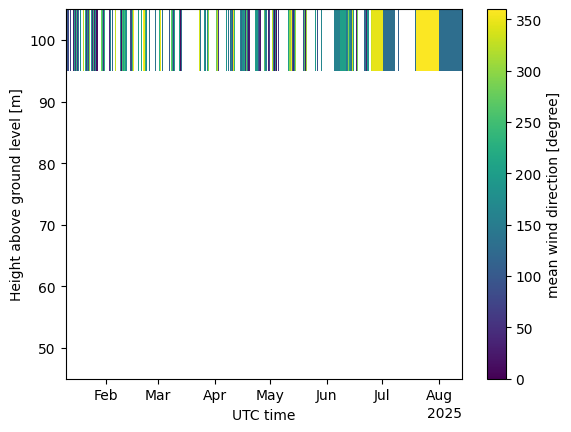

In [27]:
lidar['wd'].sel(height=slice(lidar.height.min(), 100)).transpose().plot()

While minimum height bin is 50, data doesn't start until near 100

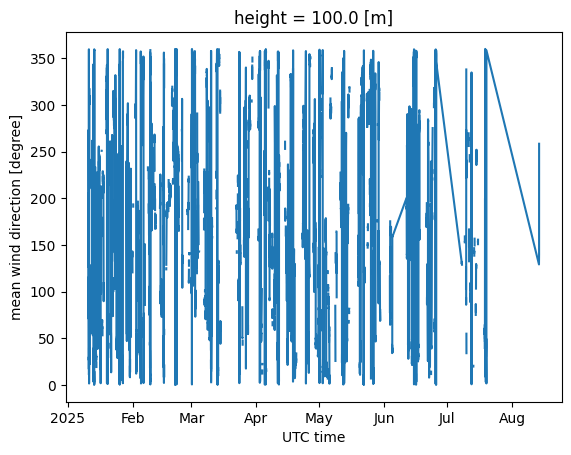

In [28]:
lidar['wd'].sel(height=100).transpose().plot()

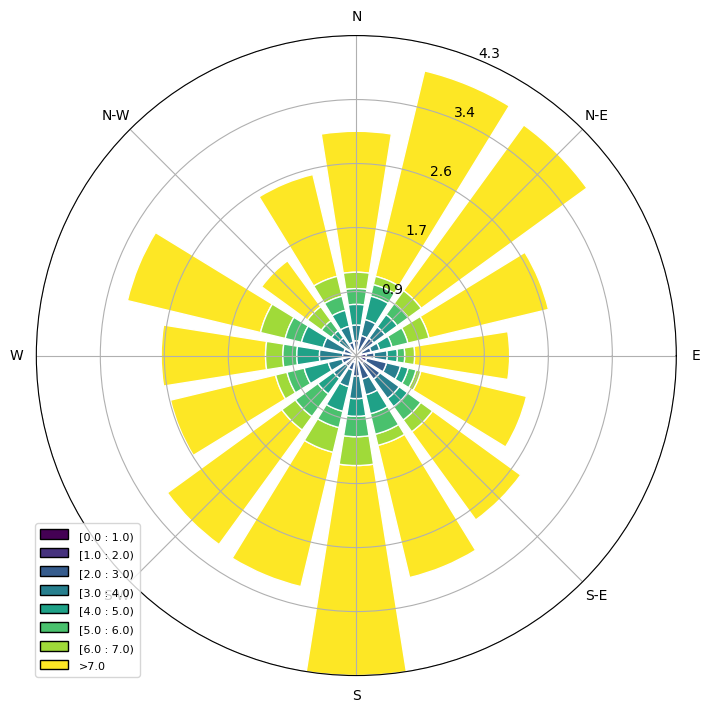

In [31]:

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)   # or WindroseAxes.from_ax()
# ax = fig.add_subplot(111, projection='windrose')  # if projection is registered
ws = lidar['ws'].sel(height=100).values  # wind speeds
wd = lidar['wd'].sel(height=100).values # wind directions
ax.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax.set_legend()

##### 2.a merged data product

In [46]:
lidar.time # every 10 minutes
ld1.time # every 10 seconds
lidar_mini = lidar[['wd', 'ti']].sel(height=100)
lidar_mini = lidar_mini.drop_vars('height')
lidar_mini.attrs["height"] = "100m"

ld1_mini = ld1[['rain_intensity', 'weather_code_nws','radar_reflectivity',
                'visibility']]   

ds = xr.merge([ld1_mini, lidar_mini], join='left')


#### 3. Initial look at disdrometer data

There appear to be 2 dominate wind directions, lets separate the different events and gather their statistics

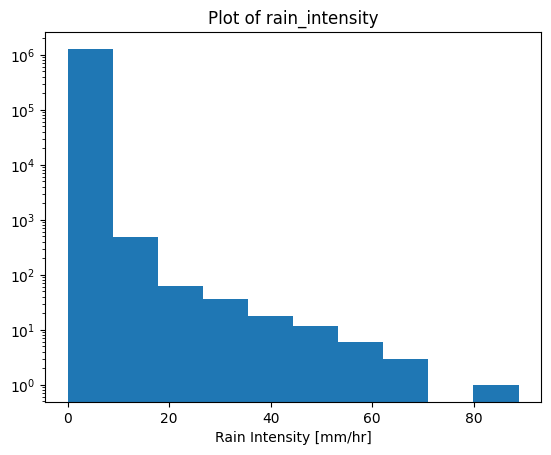

In [ ]:
plt.figure()
da = ld1['rain_intensity']
# da.where(da > 0).plot.hist()
da.plot.hist()
plt.title(f"Plot of {'rain_intensity'}")
plt.yscale('log')
plt.show()

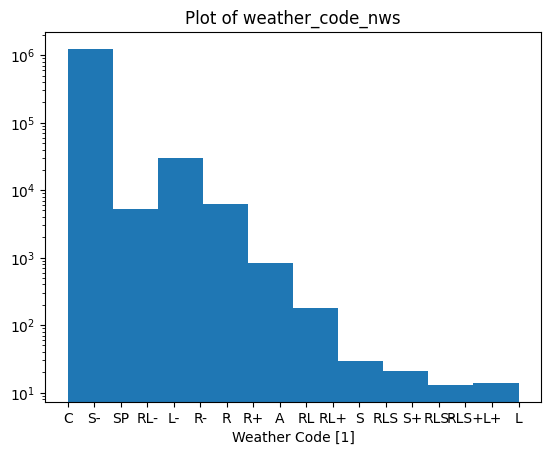

In [ ]:
plt.figure()
da = ld1['weather_code_nws']
# da.where(da > 0).plot.hist()
da.plot.hist()
plt.title(f"Plot of {'weather_code_nws'}")
plt.yscale('log')
plt.show()

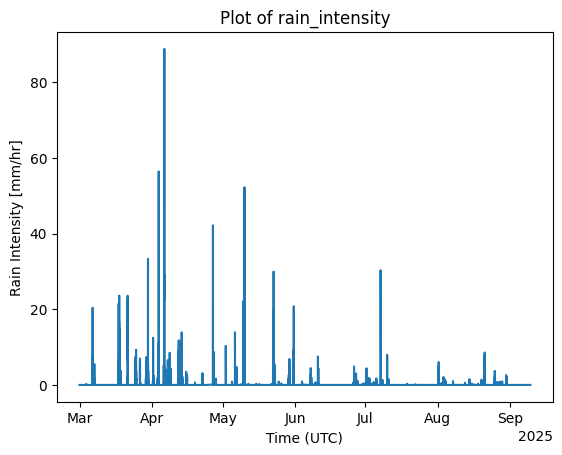

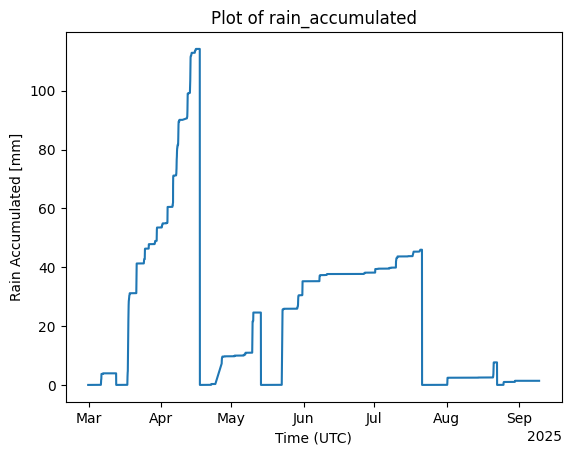

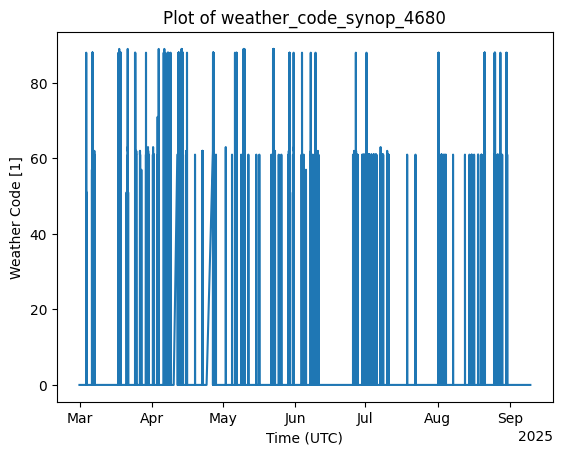

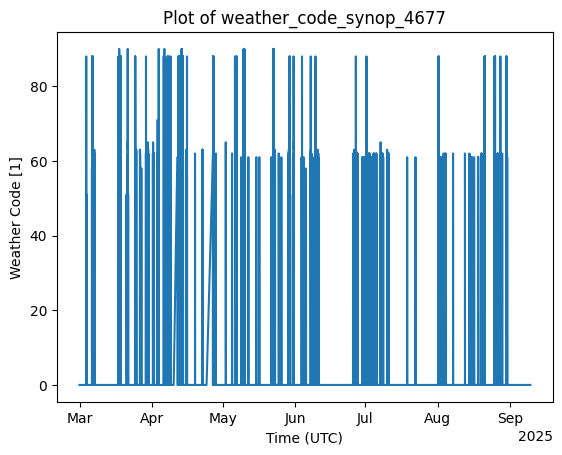

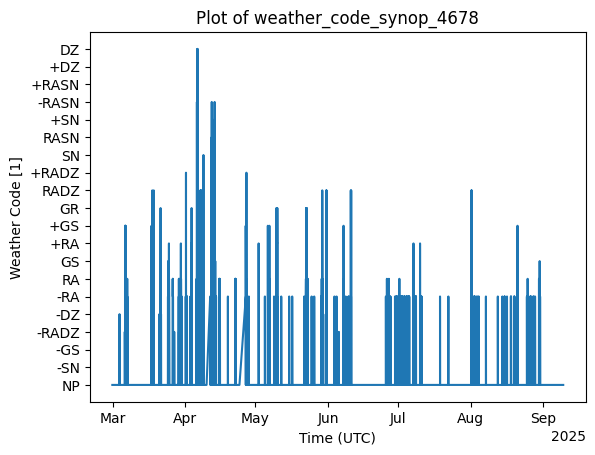

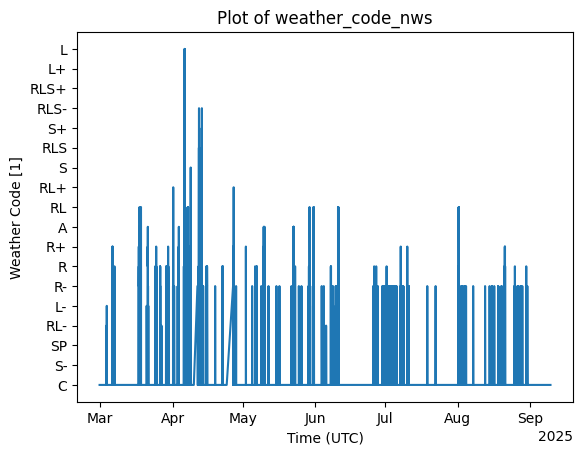

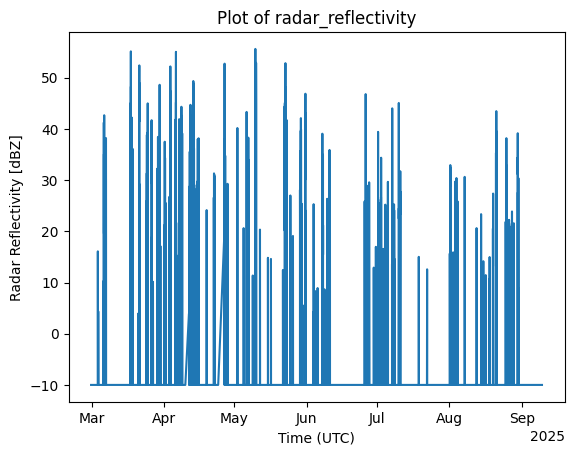

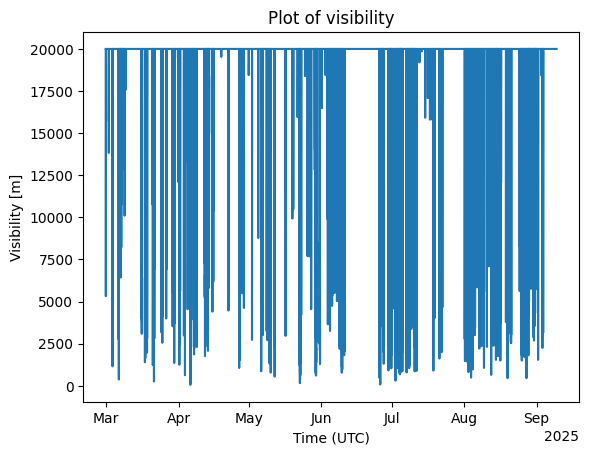

In [ ]:
for var_name in list(ld1.data_vars)[:8]:# ld1.data_vars:
    plt.figure()
    ld1[var_name].plot()
    plt.title(f"Plot of {var_name}")
    plt.show()

Now we've seen the total time series. Lets pick one event

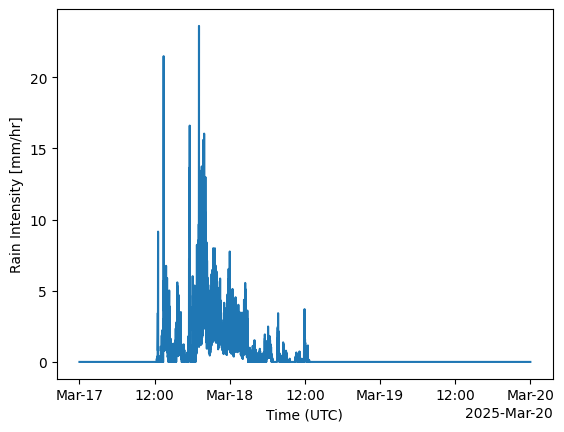

In [ ]:
ld1['rain_intensity'].sel(time=slice('2025-03-17', '2025-03-18')).plot()

#### 4. Lets extract all events

In [47]:
# Find Separate Rain Events

def extract_rain_events_xr(
    ds: xr.Dataset,
    rain_var="rain_intensity",
    time_dim="time",
    rain_threshold=0.0,
    max_dry_gap="5min",        # merge wet runs separated by <= this dry gap
    min_event_duration="10min" # drop events shorter than this
):
    ds = ds.sortby(time_dim)

    t = ds[time_dim].to_index()
    if not isinstance(t, pd.DatetimeIndex):
        raise ValueError(f"{time_dim} must be datetime-like")

    wet = (ds[rain_var].fillna(0) > rain_threshold).astype(bool).values
    n = wet.size
    if n == 0:
        return xr.Dataset(), ds.assign(event_id=xr.full_like(ds[time_dim], np.nan, dtype=float))

    # Identify wet runs (start/end indices) on the raw wet mask
    wet_int = wet.astype(np.int8)
    d = np.diff(wet_int, prepend=0, append=0)
    starts = np.where(d == 1)[0]
    ends_excl = np.where(d == -1)[0]  # exclusive
    ends = ends_excl - 1              # inclusive

    if len(starts) == 0:
        event_id = xr.DataArray(np.full(n, np.nan), coords={time_dim: ds[time_dim]}, dims=(time_dim,))
        return xr.Dataset(), ds.assign(event_id=event_id)

    # Merge runs separated by short dry gaps
    max_gap = pd.to_timedelta(max_dry_gap)
    merged = []
    cur_s, cur_e = starts[0], ends[0]
    for s, e in zip(starts[1:], ends[1:]):
        gap = t[s] - t[cur_e]  # time between last wet point and next wet start
        if gap <= max_gap:
            cur_e = e
        else:
            merged.append((cur_s, cur_e))
            cur_s, cur_e = s, e
    merged.append((cur_s, cur_e))

    # Build events and apply min duration
    min_dur = pd.to_timedelta(min_event_duration)
    event_rows = []
    for i, (s, e) in enumerate(merged, start=1):
        start_time = t[s]
        end_time = t[e]
        duration = end_time - start_time
        if duration >= min_dur:
            event_rows.append((i, start_time, end_time, duration))

    events = pd.DataFrame(event_rows, columns=["event_id", "start", "end", "duration"])

    # Label time points with event_id
    labels = np.full(n, np.nan)
    for _, r in events.iterrows():
        # indices for this event
        s = t.get_loc(r["start"])
        e = t.get_loc(r["end"])
        labels[s:e+1] = r["event_id"]

    event_id = xr.DataArray(labels, coords={time_dim: ds[time_dim]}, dims=(time_dim,))
    ds_labeled = ds.assign(event_id=event_id)

    # Return events also as xarray Dataset (optional)
    events_ds = xr.Dataset(
        data_vars=dict(
            start=("event", events["start"].values.astype("datetime64[ns]")),
            end=("event", events["end"].values.astype("datetime64[ns]")),
            duration=("event", events["duration"].values.astype("timedelta64[ns]")),
            event_id=("event", events["event_id"].values.astype(int)),
        ),
        coords=dict(event=np.arange(len(events)))
    )

    return events_ds, ds_labeled

# events_ds, ds_labeled = extract_rain_events_xr(
#     ds,
#     rain_var="rain_intensity",
#     max_dry_gap="5min",
#     min_event_duration="10min"
# )

# events_ds
# ds_labeled has ds_labeled["event_id"] aligned with time; NaN means not in a kept event

In [57]:
def circular_mean_deg_xr(da_deg, dim="time"):
    rad = np.deg2rad(da_deg)
    mean_sin = xr.apply_ufunc(np.sin, rad).mean(dim)
    mean_cos = xr.apply_ufunc(np.cos, rad).mean(dim)
    ang = xr.apply_ufunc(np.arctan2, mean_sin, mean_cos)
    return (xr.apply_ufunc(np.rad2deg, ang) + 360) % 360

def per_event_stats(ds_labeled, time_dim="time",
                    rain_var="rain_intensity",
                    wind_var="wd",
                    viz_var="visibility",
                    dbz_var="radar_reflectivity",
                    codes_var="weather_code_nws",
                    turb_var="ti",
                    dt_seconds=10):
    """
    ds_labeled must contain:
      - ds_labeled[rain_var] in mm/hour
      - ds_labeled[wind_var] in degrees
      - ds_labeled["event_id"] labeling timesteps (NaN when not in an event)

    Computes per-event:
      start, duration, rain_sum_mm, rain_max, rain_median, wind_dir_mean
    """
    # keep only event times, group by event_id
    g = ds_labeled.where(ds_labeled["event_id"].notnull(), drop=True).groupby("event_id")

    # Convert mm/hour samples to mm per sample:
    # mm/hr * (dt_seconds / 3600) = mm
    rain_mm_per_step = ds_labeled[rain_var] * (dt_seconds / 3600.0)

    def one_event(d):
        start = d[time_dim].min(time_dim)
        end   = d[time_dim].max(time_dim)
        duration = end - start

        rain_sum_mm = (rain_mm_per_step.sel({time_dim: d[time_dim]})).sum(time_dim).compute()
        rain_max = d[rain_var].max(time_dim).compute()
        rain_mean = d[rain_var].mean(time_dim).compute()
        visibility_mean = d[viz_var].mean(time_dim).compute()
        dbz_mean = d[dbz_var].mean(time_dim).compute()
        codes_unique = np.unique(d[codes_var].compute().values)
        wind_dir_mean = circular_mean_deg_xr(d[wind_var].compute(), dim=time_dim)
        ti_mean = d[turb_var].mean(time_dim).compute()

        return xr.Dataset(
            {
                "start": start,
                "duration": duration,
                "rain_sum_mm": rain_sum_mm,
                "rain_max_intensity": rain_max,
                "rain_mean_intensity": rain_mean,
                "wind_dir_mean": wind_dir_mean,
                "visibility_mean": visibility_mean,
                "dbz_mean": dbz_mean,
                "codes_unique": codes_unique,
                "ti_mean": ti_mean
            }
        )

    return g.map(one_event)

# usage:
# per_event = per_event_stats(ds_labeled, dt_seconds=10)
# per_event

In [30]:
def plot_rain_event(ds_labeled, per_event, event_id,
                    time_dim="time",
                    vars_to_plot=("rain_intensity", "radar_reflectivity", "visibility", "ti", "wd"),
                    wind_var="wd",
                    ti_var="ti",
                    rain_var="rain_intensity"):
    """
    Plot time series for one labeled event.

    Parameters
    ----------
    ds_labeled : xr.Dataset
        Must contain event_id(time_dim) plus the variables you want to plot.
    per_event : xr.Dataset
        Per-event stats with dim 'event_id' (as produced by your groupby-map).
        Must include the fields listed in your message.
    event_id : int
        Which event to plot.
    vars_to_plot : tuple[str]
        Variables to plot as separate subplots (if present in ds_labeled).
    """

    if "event_id" not in ds_labeled:
        raise ValueError("ds_labeled must include variable 'event_id'")

    # Select event slice
    m = ds_labeled["event_id"] == event_id
    if m.sum().item() == 0:
        raise ValueError(f"No samples found for event_id={event_id}")

    dse = ds_labeled.where(m, drop=True)

    # Pull per-event metadata (handle xarray scalars)
    pe = per_event.sel(event_id=event_id)

    def _scalar(x):
        try:
            return x.item()
        except Exception:
            return x.values

    start = _scalar(pe["start"]) if "start" in pe else dse[time_dim].min().item()
    duration = _scalar(pe["duration"]) if "duration" in pe else (dse[time_dim].max() - dse[time_dim].min()).item()

    codes = None
    if "weather_code_nws" in dse:
        # codes = _scalar(dse["weather_code_nws"])
        codes = np.unique(dse["weather_code_nws"].values)

    # Title text
    title_parts = [f"Event {event_id}", f"start={pd.to_datetime(start)}", f"duration={pd.to_timedelta(duration)}"]
    if codes is not None:
        title_parts.append(f"codes={codes}")
    title = " | ".join(title_parts)

    # Figure
    existing = [v for v in vars_to_plot if v in dse.data_vars]
    n = len(existing)
    if n == 0:
        raise ValueError("None of vars_to_plot exist in ds_labeled")

    fig, axes = plt.subplots(n, 1, figsize=(12, 2.6*n), sharex=True, constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, v in zip(axes, existing):
        ax.plot(dse[time_dim].values, dse[v].values, lw=1.2)
        ax.set_ylabel(v)
        ax.grid(True, alpha=0.25)

        # Optional: highlight raining vs not (within event window it should mostly be rain,
        # but if you merged across small dry gaps you may see zeros)
        if v == rain_var:
            ax.axhline(0, color="k", lw=0.8, alpha=0.4)
        if v == wind_var or v == ti_var:
            ax.plot(dse[time_dim].values, dse[v].values, lw=1.2, marker='o', markersize=20, alpha=0.7)
            

    # Add a small per-event stats block on the first axis
    stats_lines = []
    for k in ["rain_sum_mm", "rain_max_intensity", "rain_mean_intensity",
              "wind_dir_mean", "visibility_mean", "dbz_mean", "ti_mean"]:
        if k in pe:
            val = _scalar(pe[k])
            stats_lines.append(f"{k}={val:.3g}" if np.isscalar(val) and np.isfinite(val) else f"{k}={val}")
    if stats_lines:
        axes[0].text(0.01, 0.98, "\n".join(stats_lines),
                     transform=axes[0].transAxes, va="top", ha="left",
                     fontsize=9, family="monospace",
                     bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85))

    axes[0].set_title(title)
    axes[-1].set_xlabel(time_dim)

    return fig, axes

In [ ]:
events_ds, ds_labeled = extract_rain_events_xr(
    ds,
    rain_var="rain_intensity",
    max_dry_gap="5min",
    min_event_duration="10min"
)

per_event = per_event_stats(ds_labeled, dt_seconds=10)
per_event 

Per event doesn't work correctly when it comes to picking out the weather codes

In [52]:
ds_labeled = xr.open_dataset("/qfs/people/gold396/ORACLE/nant_ds_labeled.nc")
events_ds = xr.open_dataset("/qfs/people/gold396/ORACLE/nant_events_ds.nc")
per_event = xr.open_dataset("/qfs/people/gold396/ORACLE/nant_per_event.nc")
per_event_nogaps = xr.open_dataset("/qfs/people/gold396/ORACLE/nant_per_event_processed.nc")

Lets pick an event

In [15]:
for var_name in events_ds.data_vars:
    print(f"Variable: {var_name}")
    print(events_ds.sel(event=events_ds.event[50])[var_name].values)

Variable: start
2025-04-11T23:25:00.000000000
Variable: end
2025-04-11T23:43:50.000000000
Variable: duration
1130000000000 nanoseconds
Variable: event_id
115


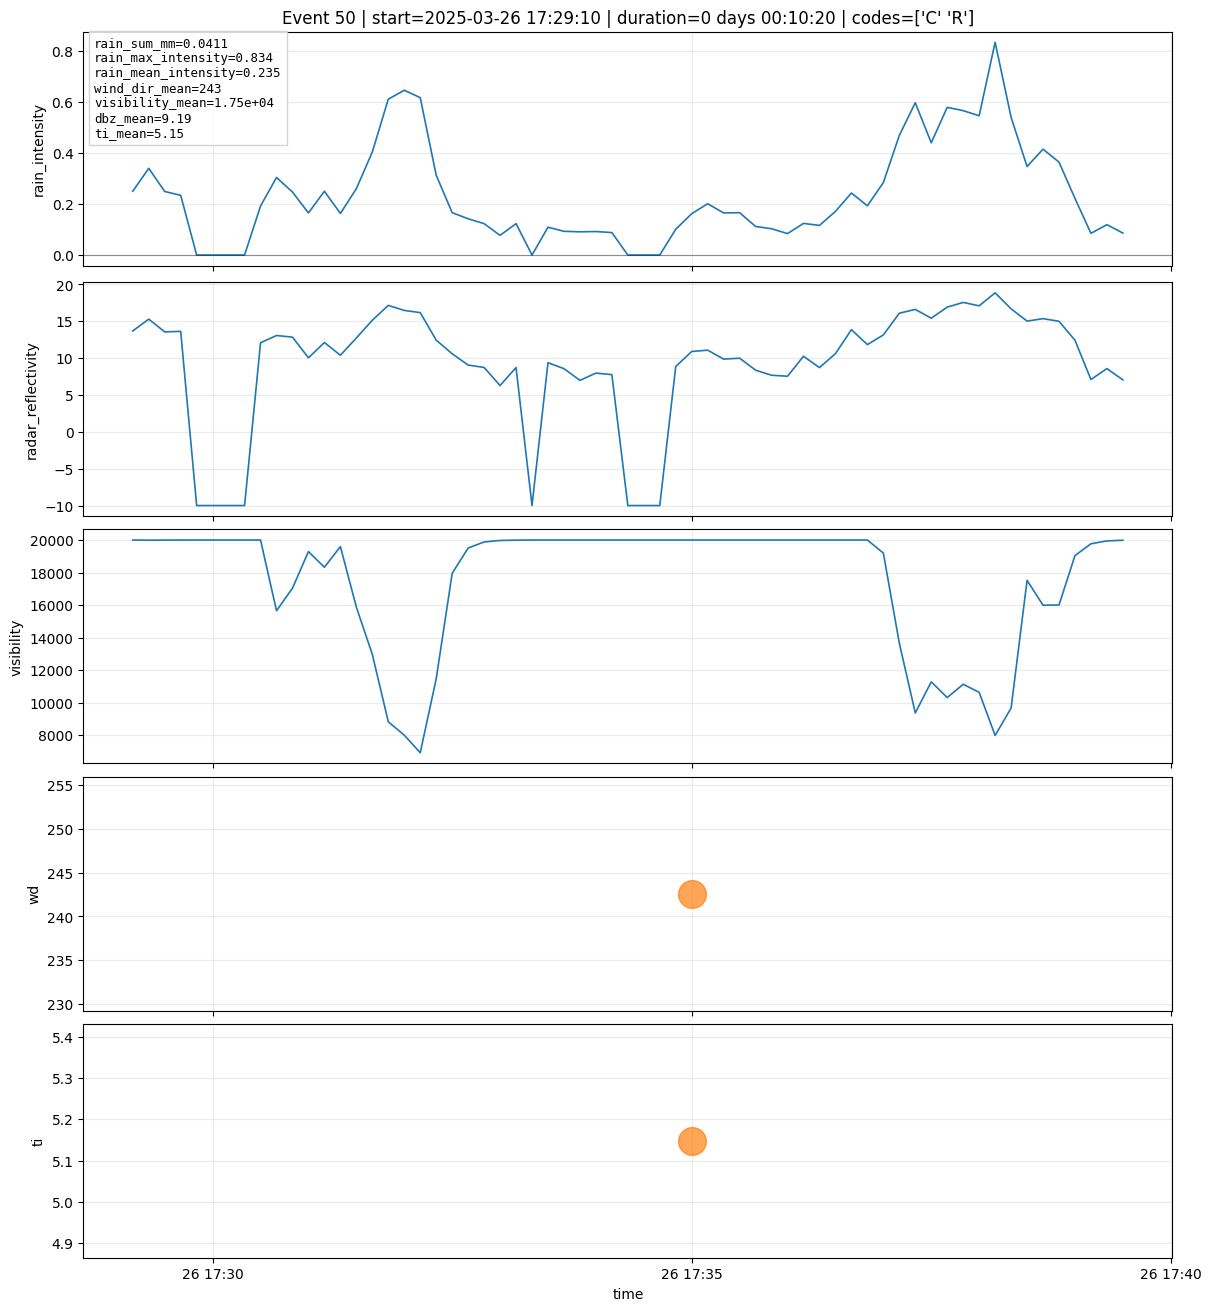

In [31]:
fig, axes = plot_rain_event(
    ds_labeled, per_event, event_id=50,
    vars_to_plot=("rain_intensity", "radar_reflectivity", "visibility","wd","ti")
)
plt.show()

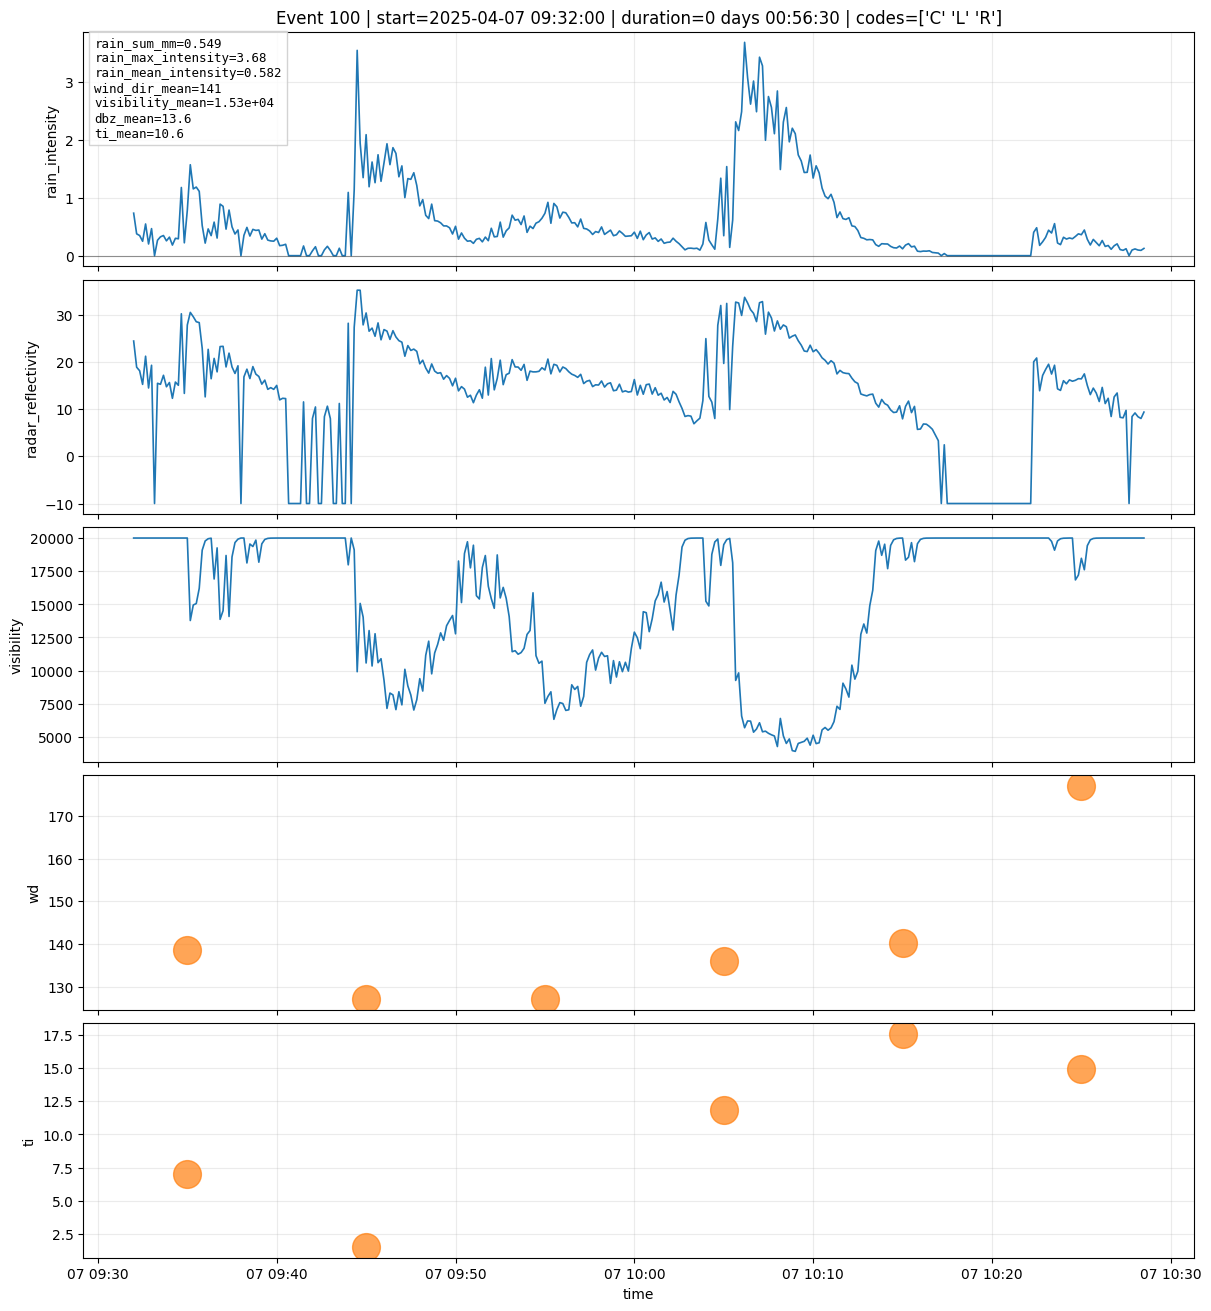

In [32]:
fig, axes = plot_rain_event(
    ds_labeled, per_event, event_id=100,
    vars_to_plot=("rain_intensity", "radar_reflectivity", "visibility","wd","ti")
)
plt.show()

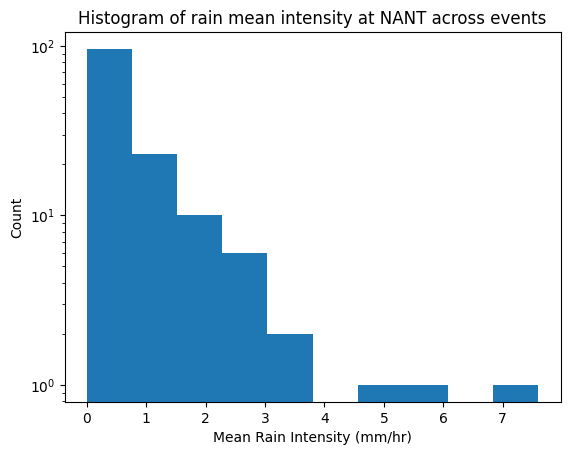

In [37]:
per_event.rain_mean_intensity.plot.hist()
plt.title("Histogram of rain mean intensity at NANT across events")
plt.xlabel("Mean Rain Intensity (mm/hr)")
plt.ylabel("Count")
plt.yscale('log')
plt.show()

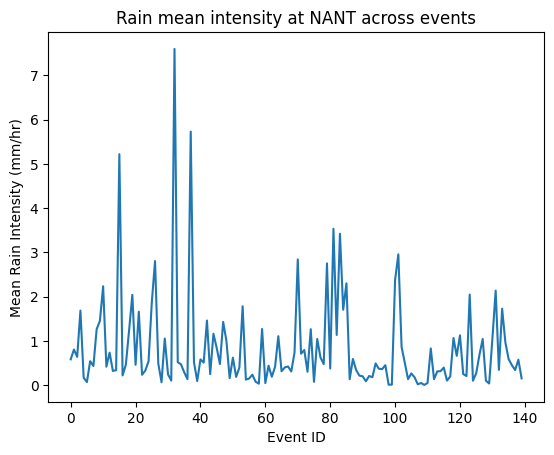

In [53]:
per_event_nogaps.rain_mean_intensity.plot()
plt.title("Rain mean intensity at NANT across events")
plt.ylabel("Mean Rain Intensity (mm/hr)")
plt.xlabel("Event ID")
plt.show()

In [ ]:
# ds = per_event.assign_coords(event_id=range(len(per_event.event_id)))
# ds = ds.drop_vars("codes_unique")
# ds.to_netcdf("/qfs/people/gold396/ORACLE/nant_per_event_processed.nc")

#### 5. Lets try and do a little AI/ML project. Unsupervised clustering to try to find out how many modes of events occur at NANT

1) Build an event-feature table (one row per event), 
2) scale/transform features (rain is heavy-tailed; wind is circular), 
3) run clustering for a range of k and pick k with metrics (silhouette, Calinski–Harabasz, Davies–Bouldin), and 
4) interpret clusters

5.1 create features for clustering (xarray to pandas)

lets use per event dataset

In [ ]:
ds = xr.open_dataarray("/qfs/people/gold396/ORACLE/nant_per_event_processed.nc")

In [54]:
ds

<xarray.Dataset> Size: 10kB
Dimensions:              (event_id: 140)
Coordinates:
  * event_id             (event_id) int64 1kB 0 1 2 3 4 ... 135 136 137 138 139
Data variables:
    start                (event_id) datetime64[ns] 1kB ...
    duration             (event_id) timedelta64[ns] 1kB ...
    rain_sum_mm          (event_id) float64 1kB ...
    rain_max_intensity   (event_id) float64 1kB ...
    rain_mean_intensity  (event_id) float64 1kB ...
    wind_dir_mean        (event_id) float32 560B ...
    visibility_mean      (event_id) float64 1kB ...
    dbz_mean             (event_id) float64 1kB ...
    ti_mean              (event_id) float32 560B ...

In [61]:
def event_features_from_xr(ds):
    # per_event is an xr.Dataset with dim "event_id" (from groupby map)
    df = ds.to_dataframe().reset_index()

    # duration to minutes
    df["duration_min"] = pd.to_timedelta(df["duration"]).dt.total_seconds() / 60.0

    # circular wind encoding
    theta = np.deg2rad(df["wind_dir_mean"].astype(float))
    df["wind_sin"] = np.sin(theta)
    df["wind_cos"] = np.cos(theta)

    # rain_sum is already mm; add log transforms for stability
    df["log_rain_sum"] = np.log1p(df["rain_sum_mm"].astype(float))
    df["log_rain_max"] = np.log1p(df["rain_max_intensity"].astype(float))
    df["log_rain_mean"] = np.log1p(df["rain_mean_intensity"].astype(float))
    df["log_visibility_mean"] = np.log1p(df["visibility_mean"].astype(float))
    df["log_dbz_mean"] = np.log1p(df["dbz_mean"].astype(float))
    df["log_ti_mean"] = np.log1p(df["ti_mean"].astype(float))
    df["log_duration"] = np.log1p(df["duration_min"].astype(float))
 
    # Keep a compact feature set (tune as you like)
    # feat_cols = ["log_rain_sum", "log_rain_max", "log_rain_mean", 
    #              "log_duration", "wind_sin", "wind_cos",
    #              "log_visibility_mean", "log_dbz_mean", "log_ti_mean"]
    feat_cols = ["log_rain_sum", "log_rain_max", "log_rain_mean", 
                "log_duration", "log_visibility_mean", "log_dbz_mean"]

    X = df[feat_cols].replace([np.inf, -np.inf], np.nan).dropna()
    df = df.loc[X.index].reset_index(drop=True)
    X = X.to_numpy()

    return df, X, feat_cols

df_events, X, feat_cols = event_features_from_xr(ds)
df_events.tail()

,event_id,start,duration,rain_sum_mm,rain_max_intensity,rain_mean_intensity,wind_dir_mean,visibility_mean,dbz_mean,ti_mean,duration_min,wind_sin,wind_cos,log_rain_sum,log_rain_max,log_rain_mean,log_visibility_mean,log_dbz_mean,log_ti_mean,log_duration
120,135,2025-08-25 08:13:40,0 days 01:13:50,0.724711,3.703,0.587604,NaN,17691.781532,14.221541,NaN,73.833333,NaN,NaN,0.545060,1.548201,0.462226,9.780912,2.722712,NaN,4.315263
121,136,2025-08-25 09:34:20,0 days 00:21:00,0.159503,2.201,0.452134,NaN,18623.362205,12.785480,NaN,21.000000,NaN,NaN,0.147991,1.163463,0.373034,9.832226,2.623616,NaN,3.091042
122,137,2025-08-25 11:36:30,0 days 00:16:10,0.092767,1.223,0.340776,NaN,14757.653061,11.316296,NaN,16.166667,NaN,NaN,0.088713,0.798858,0.293248,9.599585,2.510923,NaN,2.842970
123,138,2025-08-30 05:17:00,0 days 00:35:10,0.338631,2.621,0.575033,NaN,17416.311321,15.496094,NaN,35.166667,NaN,NaN,0.291647,1.286750,0.454276,9.765220,2.803124,NaN,3.588138
124,139,2025-08-30 06:45:50,0 days 00:14:30,0.037514,1.024,0.153466,NaN,19879.147727,0.259898,NaN,14.500000,NaN,NaN,0.036827,0.705076,0.142771,9.897477,0.231031,NaN,2.740840


In [116]:
df_events.loc[48]

event_id                                50
start                  2025-04-11 23:25:00
duration                   0 days 00:18:50
rain_sum_mm                       0.196647
rain_max_intensity                   2.137
rain_mean_intensity               0.620991
wind_dir_mean                   208.849991
visibility_mean               19135.008772
dbz_mean                         15.092939
ti_mean                             11.516
duration_min                     18.833333
wind_sin                         -0.482518
wind_cos                         -0.875886
log_rain_sum                      0.179524
log_rain_max                      1.143267
log_rain_mean                     0.483038
log_visibility_mean               9.859327
log_dbz_mean                      2.778381
log_ti_mean                       2.527008
log_duration                      2.987364
cluster                                  0
Name: 48, dtype: object

In [118]:
df_events.loc[91]

event_id                               100
start                  2025-05-31 08:20:30
duration                   0 days 01:32:10
rain_sum_mm                       3.662994
rain_max_intensity                   9.316
rain_mean_intensity               2.380285
wind_dir_mean                          NaN
visibility_mean                9632.554152
dbz_mean                         27.974977
ti_mean                                NaN
duration_min                     92.166667
wind_sin                               NaN
wind_cos                               NaN
log_rain_sum                      1.539658
log_rain_max                      2.333696
log_rain_mean                      1.21796
log_visibility_mean               9.173008
log_dbz_mean                      3.366433
log_ti_mean                            NaN
log_duration                       4.53439
cluster                                  1
Name: 91, dtype: object

Problem is that per event didn't capture winds or ti correctly most of the time, so after processing, only 23 rows of data make the cut if these variables are included for now

#### 5.2 Choosing clusters and fit (k-means)

In [ ]:
# ! python -m pip install matplotlib-venn --quiet

In [ ]:
# ! python -m pip install scikit-learn --quiet

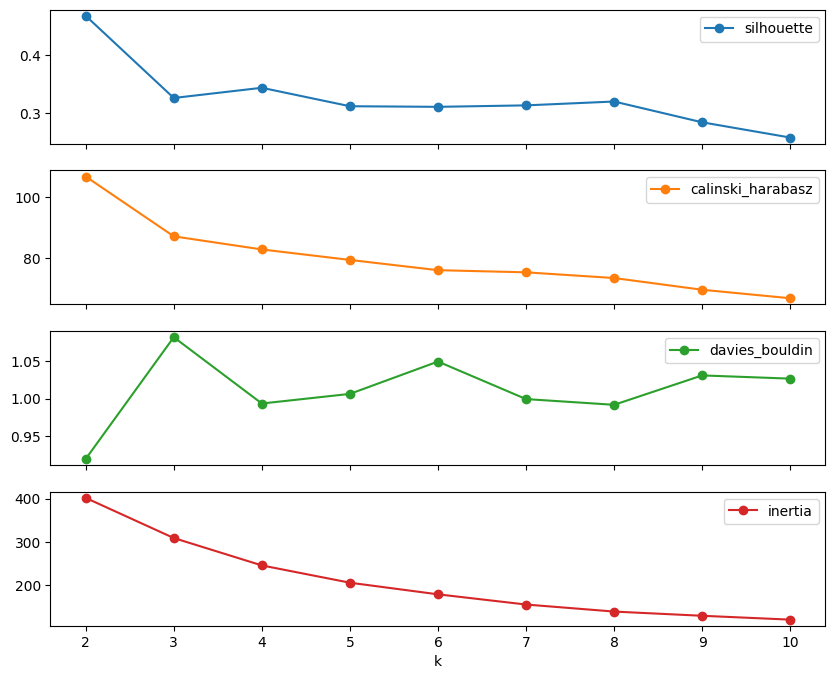

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

scaler = StandardScaler()
Xs = scaler.fit_transform(X)

scores = []
models = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=50, random_state=0)
    labels = km.fit_predict(Xs)

    scores.append({
        "k": k,
        "silhouette": silhouette_score(Xs, labels),
        "calinski_harabasz": calinski_harabasz_score(Xs, labels),
        "davies_bouldin": davies_bouldin_score(Xs, labels),
        "inertia": km.inertia_,
    })
    models[k] = km

scores_df = pd.DataFrame(scores).sort_values("k")
scores_df.plot(x="k", y=["silhouette", "calinski_harabasz", "davies_bouldin", "inertia"], subplots=True, figsize=(10, 8), marker='o')
plt.show()

In [66]:
k_best = scores_df.loc[scores_df["silhouette"].idxmax(), "k"]  # or choose manually
km = models[int(k_best)]
df_events["cluster"] = km.labels_
print(k_best)

2


#### 5.3 Interpret modes

In [68]:
summary = (
    df_events.groupby("cluster")
    .agg(
        n=("cluster", "size"),
        rain_sum_mm_med=("rain_sum_mm", "median"),
        rain_max_med=("rain_max_intensity", "median"),
        rain_mean_med=("rain_mean_intensity", "median"),
        duration_min_med=("duration_min", "median"),
        viz_mean_med=("visibility_mean", "median"),
        dbz_mean_med=("dbz_mean", "median"),
    )
    .sort_values("n", ascending=False)
)
summary

,n,rain_sum_mm_med,rain_max_med,rain_mean_med,duration_min_med,viz_mean_med,dbz_mean_med
cluster,,,,,,,
0,93,0.159503,2.1370,0.396659,21.500000,17950.165803,10.221659
1,32,2.082608,12.8455,1.825535,85.833333,10866.927840,23.779665


In [71]:
print(df_events[df_events['cluster'] == 1].head())

    event_id               start        duration  rain_sum_mm  \
3          3 2025-03-06 09:30:00 0 days 01:03:30     1.787369   
7          8 2025-03-17 13:23:00 0 days 03:23:30     4.291894   
8          9 2025-03-17 17:12:30 0 days 00:37:20     0.906867   
9         10 2025-03-17 17:58:50 0 days 10:24:20    23.250933   
14        15 2025-03-21 08:29:20 0 days 01:54:10     9.943886   

    rain_max_intensity  rain_mean_intensity  wind_dir_mean  visibility_mean  \
3               20.413             1.684432            NaN     10566.806283   
7               21.482             1.264388            NaN     13790.208674   
8               16.602             1.450987            NaN     13950.848889   
9               23.606             2.233877     180.300018      9718.915666   
14              23.572             5.218366            NaN      5642.801749   

     dbz_mean  ti_mean  ...  wind_sin  wind_cos  log_rain_sum  log_rain_max  \
3   22.264563      NaN  ...       NaN       NaN      1.

In [87]:
summary

,n,rain_sum_mm_med,rain_max_med,rain_mean_med,duration_min_med,viz_mean_med,dbz_mean_med
cluster,,,,,,,
0,93,0.159503,2.1370,0.396659,21.500000,17950.165803,10.221659
1,32,2.082608,12.8455,1.825535,85.833333,10866.927840,23.779665


In [108]:
summary[summary.index == 0][k].loc[0]

np.float64(0.15950277777777777)

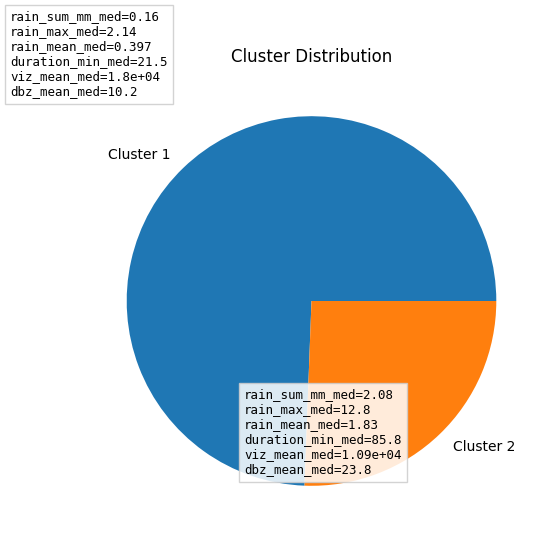

In [113]:
# Create pie plot
# Data for the pie
sizes = [93,32]
labels = ['Cluster 1', 'Cluster 2']

# Create the pie chart
fig = plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels)
plt.title("Cluster Distribution")

# Add a small per-event stats block on the first axis
# Cluster 1
stats_lines = []
for k in list(summary.columns[1:]):
    if k in list(summary.columns[1:]):
        val = (summary[summary.index == 0][k]).loc[0]
        stats_lines.append(f"{k}={val:.3g}" if np.isscalar(val) and np.isfinite(val) else f"{k}={val}")
if stats_lines:
    fig.text(0.01, 0.98, "\n".join(stats_lines),
                    transform=fig.transFigure, va="top", ha="left",
                    fontsize=9, family="monospace",
                    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85)) 
     
# Cluster 2
stats_lines = []
for k in list(summary.columns[1:]):
    if k in list(summary.columns[1:]):
        val = (summary[summary.index == 1][k]).loc[1]
        stats_lines.append(f"{k}={val:.3g}" if np.isscalar(val) and np.isfinite(val) else f"{k}={val}")
if stats_lines:
    fig.text(0.4, 0.35, "\n".join(stats_lines),
                    transform=fig.transFigure, va="top", ha="left",
                    fontsize=9, family="monospace",
                    bbox=dict(facecolor="white", edgecolor="0.8", alpha=0.85))

plt.show()
# df_events.plot.pie(y='clusters', figsize=(6, 6))

In [99]:
val.loc[1]

np.float64(23.779664563250876)

#### Bonus

Windrose during rain events only


In [123]:
new_ds = ds_labeled.where(ds_labeled['event_id'].notnull(), drop=True)

In [125]:
ds_labeled

<xarray.Dataset> Size: 67MB
Dimensions:             (time: 1281227)
Coordinates:
  * time                (time) datetime64[ns] 10MB 2025-02-28T18:56:40 ... 20...
Data variables:
    rain_intensity      (time) float64 10MB ...
    weather_code_nws    (time) <U1 5MB ...
    radar_reflectivity  (time) float64 10MB ...
    visibility          (time) float64 10MB ...
    wd                  (time) float32 5MB ...
    ti                  (time) float32 5MB ...
    event_id            (time) float64 10MB nan nan nan nan ... nan nan nan nan
Attributes: (12/20)
    inputs:                nant.ld.z01.b0::20250228.000000::20250301.000000
    title:                 combine_disdrometer
    description:           VAP to combine disdrometer data into daily files
    Conventions:           CF-1.6
    featureType:           timeSeries
    institution:           Wind Data Hub
    ...                    ...
    serial_number:         451216
    firmware_iop_version:  2.11.6
    firmware_dsp_version:  2.11.1
    deployment_time:       22:38:59_11.06.2024
    station_name:          Barge_1
    station_number:        PNNL

Text(0.5, 1.0, 'Windrose ignore windspeed, only looking for predominate WD during rain events')

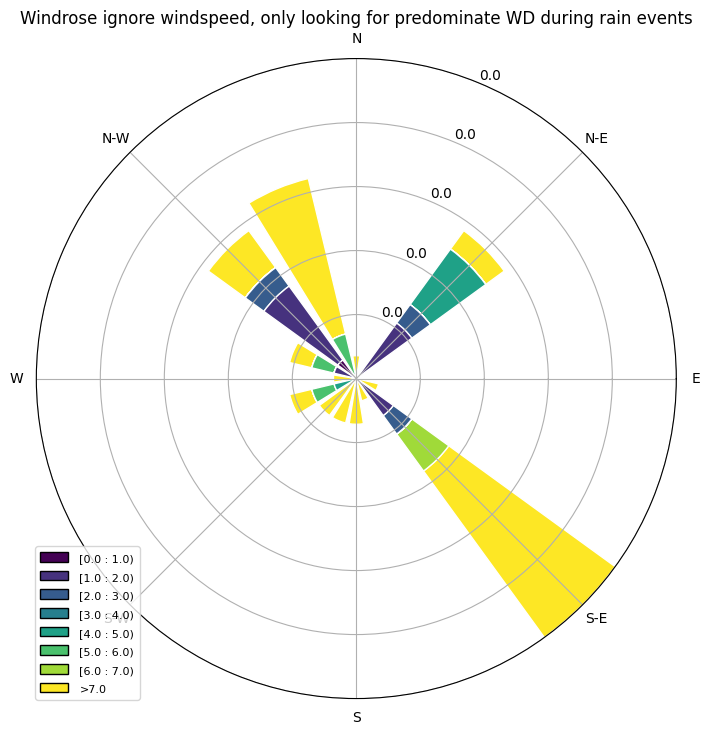

In [127]:
fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)   # or WindroseAxes.from_ax()
# ax = fig.add_subplot(111, projection='windrose')  # if projection is registered
ws = new_ds['ti'].values  # wind speeds
wd = new_ds['wd'].values # wind directions
ax.bar(wd, ws, normed=True, bins=np.arange(0, 8, 1), opening=0.8, edgecolor='white')
ax.set_legend()
ax.set_title('Windrose ignore windspeed, only looking for predominate WD during rain events')

In [ ]:
# git -C /people/gold396/ORACLE add -A && git -C /people/gold396/ORACLE commit -m "Update Initial_TimeSeries_and_Histograms notebook" && git -C /people/gold396/ORACLE push origin main